In [1]:
!git clone https://github.com/rashmi06an/EdTech-Grading-Assistant.git
%cd EdTech-Grading-Assistant

fatal: destination path 'EdTech-Grading-Assistant' already exists and is not an empty directory.
/Users/rashmianand/Desktop/EdTech-Grading-Assistant/notebooks/EdTech-Grading-Assistant


In [ ]:
import sys
import os

src_path = os.path.abspath("../src")
sys.path.insert(0, src_path)

print(src_path)

In [ ]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Add src/ directory to the python path to enable modular imports
for path in ['../src', 'src', './src']:
    abs_path = os.path.abspath(path)
    if os.path.isdir(abs_path):
        if abs_path not in sys.path:
            sys.path.append(abs_path)
from loader import load_mnist
from scaler import scale_pixels_custom, stratified_partition
from svm_classifier import (
    train_baseline,
    train_rbf_svm,
    run_grid_search,
    evaluate_classifier,
    plot_confusion_matrix,
    save_model
)
from random_forest import train_random_forest, evaluate_random_forest

print("All custom modules imported successfully!")


All custom modules imported successfully!


In [4]:
X, y = load_mnist(cast_to_int=True)
print(f"Dataset Loaded. Feature matrix shape: {X.shape}, Target labels shape: {y.shape}")
print(f"Unique classes: {np.unique(y)}")


Dataset Loaded. Feature matrix shape: (70000, 784), Target labels shape: (70000,)
Unique classes: [0 1 2 3 4 5 6 7 8 9]


In [5]:
# Scale features
X_scaled = scale_pixels_custom(X)

# Split data
X_train, X_test, y_train, y_test = stratified_partition(
    X_scaled, y,
    train_size=20000,
    test_size=5000,
    random_state=42
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print(f"Pixel range: min={X_train.min():.1f}, max={X_train.max():.1f}")


X_train shape: (20000, 784), y_train shape: (20000,)
X_test shape: (5000, 784), y_test shape: (5000,)
Pixel range: min=0.0, max=1.0


In [6]:
# Train baseline Linear SVM
baseline_model, y_pred_baseline, t_baseline = train_baseline(X_train, y_train, X_test, y_test)

# Evaluate
_, acc_base, p_base, r_base, f1_base, report_base = evaluate_classifier(
    baseline_model, X_test, y_test
)

print("\nBaseline Linear SVM Metrics:")
print(f"  Accuracy:  {acc_base*100:.2f}%")
print(f"  Macro F1:  {f1_base*100:.2f}%")
print(f"  Train Time: {t_baseline:.2f} seconds")



Baseline Linear SVM Metrics:
  Accuracy:  92.10%
  Macro F1:  91.97%
  Train Time: 35.31 seconds


In [7]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Add src/ directory to the python path to enable modular imports
for path in ['../src', 'src', './src']:
    abs_path = os.path.abspath(path)
    if os.path.isdir(abs_path):
        if abs_path not in sys.path:
            sys.path.append(abs_path)

from loader import load_mnist
from scaler import scale_pixels_custom, stratified_partition
from svm_classifier import (
    train_baseline,
    train_rbf_svm,
    run_grid_search,
    evaluate_classifier,
    plot_confusion_matrix,
    save_model
)
from random_forest import train_random_forest, evaluate_random_forest

print("All custom modules imported successfully!")


All custom modules imported successfully!


In [8]:
X, y = load_mnist(cast_to_int=True)
print(f"Dataset Loaded. Feature matrix shape: {X.shape}, Target labels shape: {y.shape}")
print(f"Unique classes: {np.unique(y)}")


Dataset Loaded. Feature matrix shape: (70000, 784), Target labels shape: (70000,)
Unique classes: [0 1 2 3 4 5 6 7 8 9]


In [9]:
# Scale features
X_scaled = scale_pixels_custom(X)

# Split data
X_train, X_test, y_train, y_test = stratified_partition(
    X_scaled, y,
    train_size=20000,
    test_size=5000,
    random_state=42
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print(f"Pixel range: min={X_train.min():.1f}, max={X_train.max():.1f}")


X_train shape: (20000, 784), y_train shape: (20000,)
X_test shape: (5000, 784), y_test shape: (5000,)
Pixel range: min=0.0, max=1.0


In [10]:
# Train baseline Linear SVM
baseline_model, y_pred_baseline, t_baseline = train_baseline(X_train, y_train, X_test, y_test)

# Evaluate
_, acc_base, p_base, r_base, f1_base, report_base = evaluate_classifier(
    baseline_model, X_test, y_test
)

print("\nBaseline Linear SVM Metrics:")
print(f"  Accuracy:  {acc_base*100:.2f}%")
print(f"  Macro F1:  {f1_base*100:.2f}%")
print(f"  Train Time: {t_baseline:.2f} seconds")



Baseline Linear SVM Metrics:
  Accuracy:  92.10%
  Macro F1:  91.97%
  Train Time: 33.74 seconds


In [11]:
# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1, 'scale']
}

# Run Grid Search on a stratified subset of 5,000 samples
grid_search = run_grid_search(X_train, y_train, param_grid=param_grid, cv=3, subset_size=5000)
best_params = grid_search.best_params_

print("\nGrid Search Best Parameters:")
print(f"  Best C:      {best_params['C']}")
print(f"  Best Gamma:  {best_params['gamma']}")
print(f"  Best CV Acc: {grid_search.best_score_*100:.2f}%")


Fitting 3 folds for each of 12 candidates, totalling 36 fits

Grid Search Best Parameters:
  Best C:      10
  Best Gamma:  scale
  Best CV Acc: 94.98%


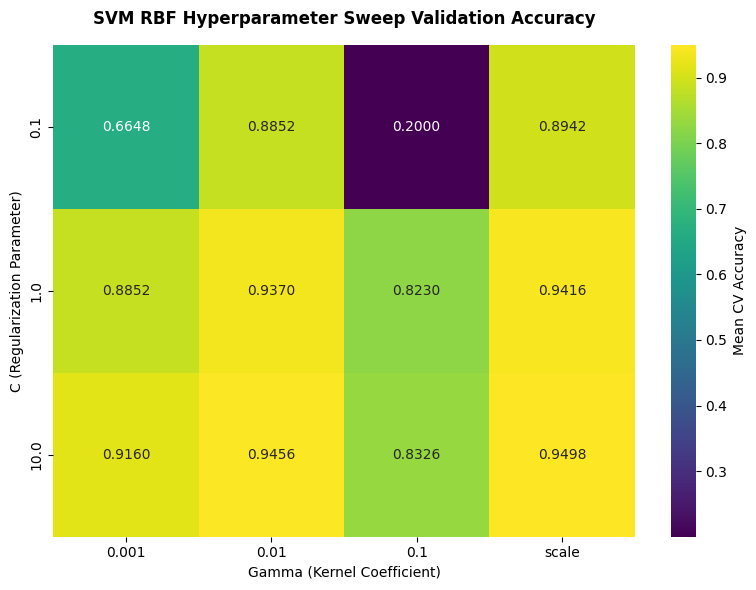

In [12]:
# Extract grid search results
results = pd.DataFrame(grid_search.cv_results_)
scores_matrix = results.pivot(index='param_C', columns='param_gamma', values='mean_test_score')

plt.figure(figsize=(8, 6))
sns.heatmap(scores_matrix, annot=True, fmt='.4f', cmap='viridis', cbar_kws={'label': 'Mean CV Accuracy'})
plt.title('SVM RBF Hyperparameter Sweep Validation Accuracy', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Gamma (Kernel Coefficient)', fontsize=10)
plt.ylabel('C (Regularization Parameter)', fontsize=10)
plt.tight_layout()
plt.show()


In [13]:
# Train RBF SVM
best_C = best_params['C']
best_gamma = best_params['gamma']
svm_opt_model, t_svm_opt = train_rbf_svm(X_train, y_train, C=best_C, gamma=best_gamma)

# Evaluate optimized SVM
y_pred_svm, acc_svm, p_svm, r_svm, f1_svm, report_svm = evaluate_classifier(
    svm_opt_model, X_test, y_test
)

print("\nOptimized RBF SVM Metrics:")
print(f"  Accuracy:   {acc_svm*100:.2f}%")
print(f"  Macro F1:   {f1_svm*100:.2f}%")
print(f"  Train Time:  {t_svm_opt:.2f} seconds")

# Save model
save_model(svm_opt_model, "../models/best_svm_model.joblib")



Optimized RBF SVM Metrics:
  Accuracy:   97.38%
  Macro F1:   97.35%
  Train Time:  222.57 seconds


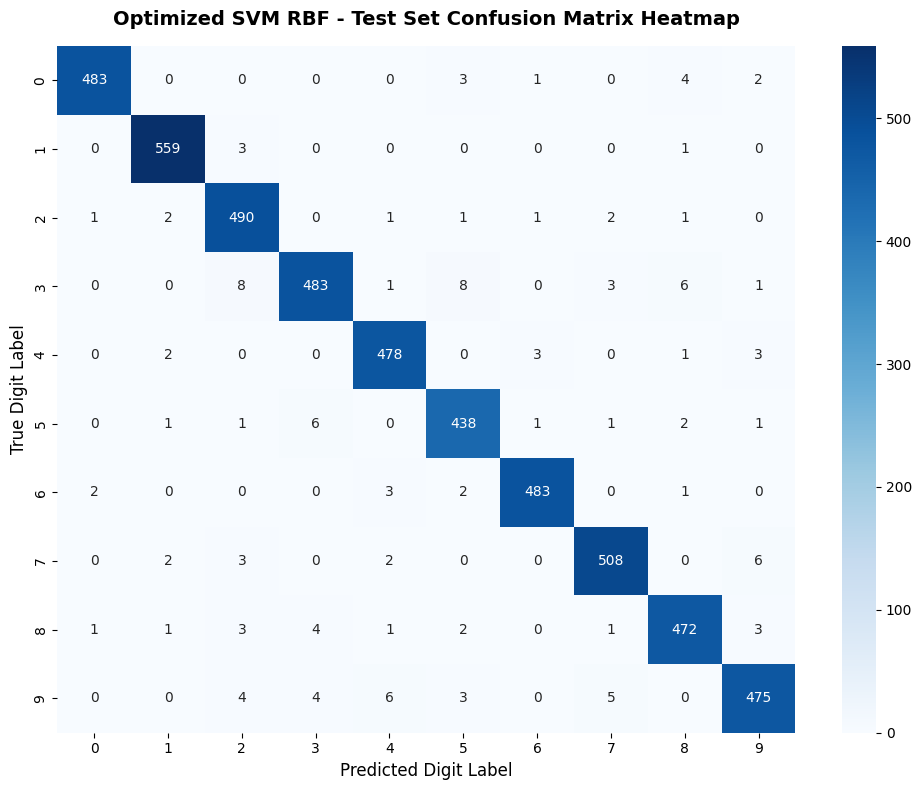

In [17]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[str(i) for i in range(10)],
    yticklabels=[str(i) for i in range(10)]
)
plt.title('Optimized SVM RBF - Test Set Confusion Matrix Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Digit Label', fontsize=12)
plt.xlabel('Predicted Digit Label', fontsize=12)
plt.tight_layout()
plt.savefig("../images/confusion_matrix.png", dpi=300)
plt.show()


In [18]:
# Train Random Forest
rf_model, t_rf_train = train_random_forest(X_train, y_train, n_estimators=100, random_state=42)

# Evaluate Random Forest
acc_rf, p_rf, r_rf, f1_rf, t_rf_pred = evaluate_random_forest(rf_model, X_test, y_test)

# Measure prediction time for SVM (on the 5,000 sample test set)
t_svm_pred_start = time.time()
_ = svm_opt_model.predict(X_test)
t_svm_pred = time.time() - t_svm_pred_start

print(f"\nRandom Forest Accuracy: {acc_rf*100:.2f}%")
print(f"Random Forest prediction time for {len(X_test)} samples: {t_rf_pred:.4f} seconds")
print(f"Optimized SVM prediction time for {len(X_test)} samples: {t_svm_pred:.4f} seconds")



Random Forest Accuracy: 95.80%
Random Forest prediction time for 5000 samples: 0.1401 seconds
Optimized SVM prediction time for 5000 samples: 29.6883 seconds


In [19]:
comparison_data = {
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1-Score", "Training Time (s)", "Prediction Time (s)"],
    "Baseline Linear SVM": [acc_base, p_base, r_base, f1_base, t_baseline, t_baseline], # Approximated pred speed
    "Optimized RBF SVM": [acc_svm, p_svm, r_svm, f1_svm, t_svm_opt, t_svm_pred],
    "Random Forest": [acc_rf, p_rf, r_rf, f1_rf, t_rf_train, t_rf_pred]
}

comparison_df = pd.DataFrame(comparison_data)
from IPython.display import display, Markdown
display(Markdown(comparison_df.to_markdown(index=False)))


| Metric              |   Baseline Linear SVM |   Optimized RBF SVM |   Random Forest |
|:--------------------|----------------------:|--------------------:|----------------:|
| Accuracy            |              0.921    |            0.9738   |        0.958    |
| Macro Precision     |              0.920291 |            0.973579 |        0.95759  |
| Macro Recall        |              0.919713 |            0.973603 |        0.9576   |
| Macro F1-Score      |              0.919677 |            0.973543 |        0.957558 |
| Training Time (s)   |             33.7409   |          222.569    |       12.7921   |
| Prediction Time (s) |             33.7409   |           29.6883   |        0.140142 |

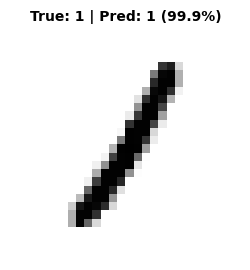

Class Probability Distribution:
  Digit 0:   0.0% | 
  Digit 1:  99.9% | ===================
  Digit 2:   0.0% | 
  Digit 3:   0.0% | 
  Digit 4:   0.0% | 
  Digit 5:   0.0% | 
  Digit 6:   0.0% | 
  Digit 7:   0.0% | 
  Digit 8:   0.0% | 
  Digit 9:   0.0% | 


In [20]:
# Pick a random sample index
idx = np.random.randint(0, len(X_test))
sample_features = X_test[idx]
true_label = y_test[idx]

# Predict
pred = svm_opt_model.predict([sample_features])[0]
probs = svm_opt_model.predict_proba([sample_features])[0]

# Plot image
plt.figure(figsize=(3, 3))
plt.imshow(sample_features.reshape(28, 28), cmap='binary')
plt.title(f"True: {true_label} | Pred: {pred} ({probs[pred]*100:.1f}%)", fontsize=10, fontweight='bold')
plt.axis('off')
plt.show()

# Print class distribution
print("Class Probability Distribution:")
for digit, prob in enumerate(probs):
    bar = "=" * int(prob * 20)
    print(f"  Digit {digit}: {prob*100:5.1f}% | {bar}")
